In [1]:
!pip install scikit-learn pandas matplotlib seaborn

  Obtaining dependency information for pyparsing<3.1,>=2.3.1 from https://files.pythonhosted.org/packages/6c/10/a7d0fa5baea8fe7b50f448ab742f26f52b80bfca85ac2be9d35cdd9a3246/pyparsing-3.0.9-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/98.3 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/98.3 kB ? eta -:--:--
   ------------------------ --------------- 61.4/98.3 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 98.3/98.3 kB 1.4 MB/s eta 0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 3.3.2
    Uninstalling pyparsing-3.3.2:
      Successfully uninstalled pyparsing-3.3.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
httplib2 0.31.2 requires pyparsing<4,>=3.1, but you have pyparsing 3.0.9 which is incompatible.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
# Load the dataset
df = pd.read_csv("train.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (159571, 8)

Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

First few rows:


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Total comments: 159,571
Toxic comments: 16,225 (10.2%)
Clean comments: 143,346 (89.8%)


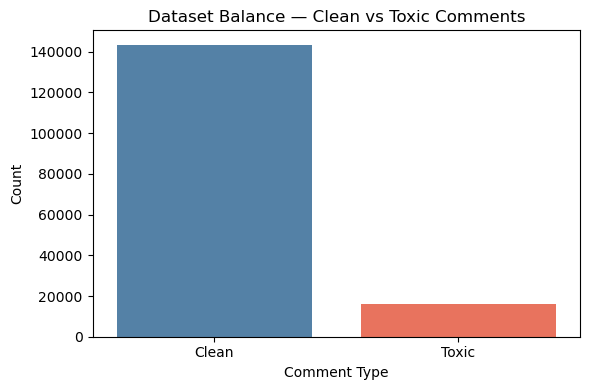

Chart saved!


In [7]:
# The dataset has multiple toxicity types - we'll create one combined "toxic" label
# A comment is toxic if it's flagged in ANY of the toxicity columns

toxicity_columns = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# Create a single label: 1 = toxic, 0 = clean
df["is_toxic"] = df[toxicity_columns].max(axis=1)

# How balanced is the dataset?
toxic_count = df["is_toxic"].sum()
clean_count = len(df) - toxic_count

print(f"Total comments: {len(df):,}")
print(f"Toxic comments: {toxic_count:,} ({toxic_count/len(df)*100:.1f}%)")
print(f"Clean comments: {clean_count:,} ({clean_count/len(df)*100:.1f}%)")

# Visualise the balance
plt.figure(figsize=(6,4))
sns.countplot(x="is_toxic", data=df, palette=["steelblue", "tomato"])
plt.xticks([0, 1], ["Clean", "Toxic"])
plt.title("Dataset Balance — Clean vs Toxic Comments")
plt.xlabel("Comment Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("dataset_balance.png", dpi=150)
plt.show()
print("Chart saved!")

In [9]:
# We'll use a sample of 50,000 to keep training fast on your machine
# but still statistically significant
df_sample = df.sample(50000, random_state=42)

# Split into features (X = the comment text) and label (y = toxic or not)
X = df_sample["comment_text"]
y = df_sample["is_toxic"]

# Split into training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples : {len(X_test):,}")

Training samples: 40,000
Testing samples : 10,000


In [11]:
# Machine learning models can't read raw text — we convert text to numbers
# TF-IDF measures how important each word is in a comment relative to all comments

vectorizer = TfidfVectorizer(
    max_features=10000,   # Use top 10,000 most important words
    stop_words="english", # Remove common words like "the", "is", "and"
    ngram_range=(1, 2)    # Consider single words AND two-word phrases
)

# Learn the vocabulary from training data and transform it
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data using the SAME vocabulary (don't relearn)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,} terms")
print(f"Training matrix shape: {X_train_tfidf.shape}")

Vocabulary size: 10,000 terms
Training matrix shape: (40000, 10000)


In [13]:
# Logistic Regression is a solid, explainable classifier
# class_weight="balanced" tells the model to pay extra attention to toxic comments
# since they're the minority class

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [15]:
# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy*100:.1f}%\n")

# Detailed breakdown — this is the important part
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Clean", "Toxic"]))

Overall Accuracy: 93.2%

Detailed Classification Report:
              precision    recall  f1-score   support

       Clean       0.98      0.95      0.96      9011
       Toxic       0.62      0.80      0.70       989

    accuracy                           0.93     10000
   macro avg       0.80      0.87      0.83     10000
weighted avg       0.94      0.93      0.94     10000



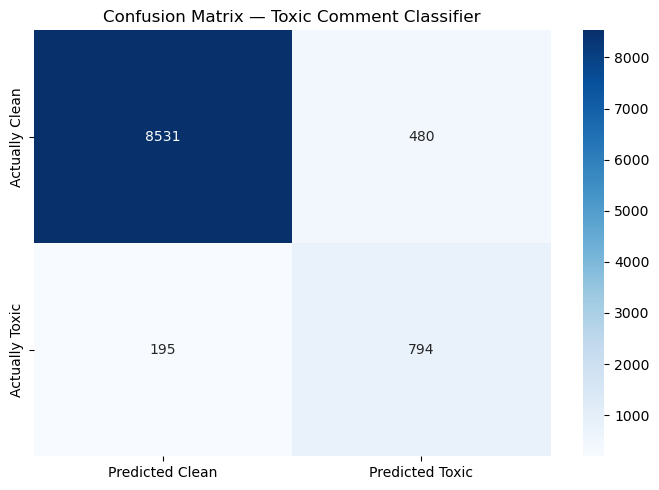

Confusion matrix saved!


In [17]:
# Confusion matrix shows exactly where the model gets it right and wrong
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Clean", "Predicted Toxic"],
            yticklabels=["Actually Clean", "Actually Toxic"])
plt.title("Confusion Matrix — Toxic Comment Classifier")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved!")

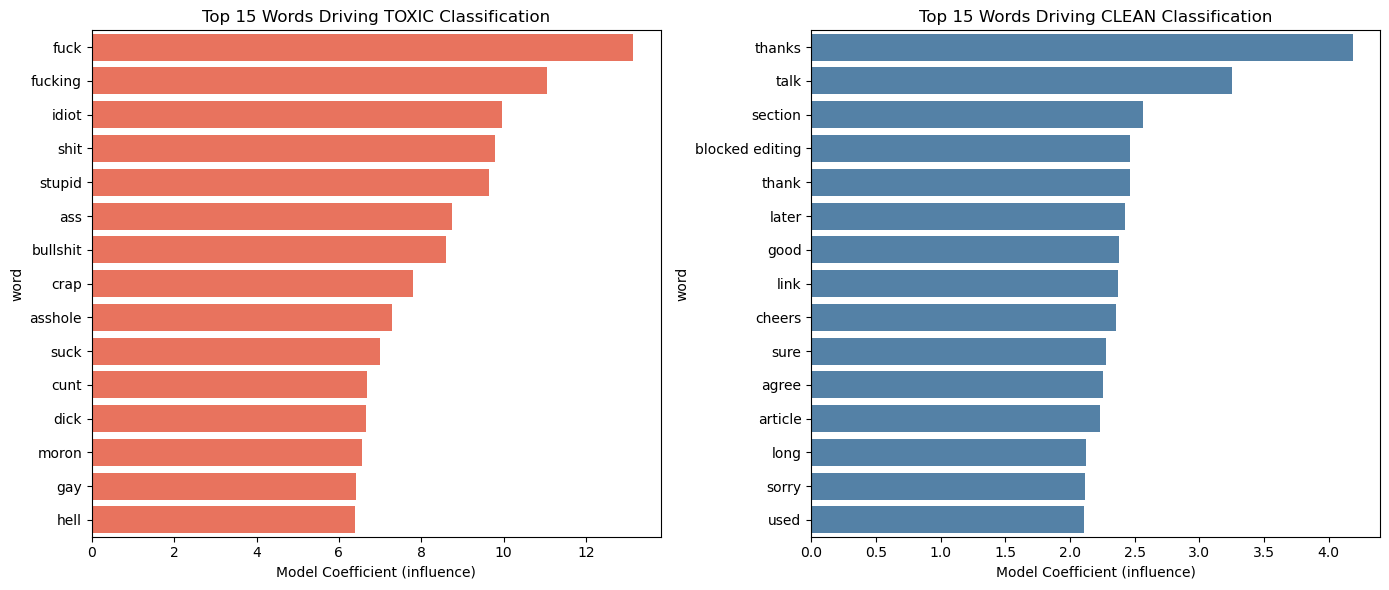

Feature importance chart saved!


In [19]:
# Extract the most toxic and most clean words the model learned
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Top 15 words associated with TOXIC comments
top_toxic_idx = coefficients.argsort()[-15:][::-1]
top_toxic_words = [(feature_names[i], coefficients[i]) for i in top_toxic_idx]

# Top 15 words associated with CLEAN comments
top_clean_idx = coefficients.argsort()[:15]
top_clean_words = [(feature_names[i], abs(coefficients[i])) for i in top_clean_idx]

# Plot them
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Toxic words
toxic_df = pd.DataFrame(top_toxic_words, columns=["word", "score"])
sns.barplot(data=toxic_df, x="score", y="word", ax=axes[0], color="tomato")
axes[0].set_title("Top 15 Words Driving TOXIC Classification")
axes[0].set_xlabel("Model Coefficient (influence)")

# Clean words
clean_df = pd.DataFrame(top_clean_words, columns=["word", "score"])
sns.barplot(data=clean_df, x="score", y="word", ax=axes[1], color="steelblue")
axes[1].set_title("Top 15 Words Driving CLEAN Classification")
axes[1].set_xlabel("Model Coefficient (influence)")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Feature importance chart saved!")

In [21]:
# This is the fun part — test the model on any comment you write
def predict_comment(comment):
    comment_tfidf = vectorizer.transform([comment])
    prediction = model.predict(comment_tfidf)[0]
    probability = model.predict_proba(comment_tfidf)[0]
    
    label = "🚨 TOXIC" if prediction == 1 else "✅ CLEAN"
    confidence = probability[prediction] * 100
    
    print(f"Comment  : {comment}")
    print(f"Result   : {label}")
    print(f"Confidence: {confidence:.1f}%")
    print("-" * 50)

# Test with some examples
predict_comment("I really enjoyed this video, great content!")
predict_comment("You are an idiot and nobody likes you")
predict_comment("This is the best tutorial I have ever seen")
predict_comment("I will find you and make you regret this")

Comment  : I really enjoyed this video, great content!
Result   : ✅ CLEAN
Confidence: 89.3%
--------------------------------------------------
Comment  : You are an idiot and nobody likes you
Result   : 🚨 TOXIC
Confidence: 99.8%
--------------------------------------------------
Comment  : This is the best tutorial I have ever seen
Result   : ✅ CLEAN
Confidence: 84.9%
--------------------------------------------------
Comment  : I will find you and make you regret this
Result   : ✅ CLEAN
Confidence: 57.0%
--------------------------------------------------


In [25]:
# Save predictions on test set
results_df = X_test.reset_index(drop=True).to_frame()
results_df["actual"] = y_test.reset_index(drop=True)
results_df["predicted"] = y_pred
results_df["correct"] = results_df["actual"] == results_df["predicted"]

# Save to CSV
results_df.to_csv("classification_results.csv", index=False)

# Generate summary report
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["Clean", "Toxic"])

summary = f"""
============================================================
  TOXIC COMMENT CLASSIFICATION REPORT
============================================================
Model          : Logistic Regression (TF-IDF features)
Dataset        : Jigsaw Toxic Comment Classification
Training size  : 40,000 comments
Test size      : 10,000 comments
Date Generated : {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}

------------------------------------------------------------
DATASET OVERVIEW
------------------------------------------------------------
Total comments analysed : 159,571
Toxic comments          : 16,225 (10.2%)
Clean comments          : 143,346 (89.8%)

------------------------------------------------------------
MODEL PERFORMANCE
------------------------------------------------------------
Overall Accuracy: {accuracy*100:.1f}%

{report}
------------------------------------------------------------
KEY OBSERVATIONS
------------------------------------------------------------
1. Model performs strongly on explicit toxicity (profanity-based)
2. Implicit threats without profanity are harder to detect
   e.g. "I will find you and make you regret this" classified as Clean
   This reflects a known limitation of keyword-based ML models
3. False negative rate (missing toxic comments) is the critical 
   metric in Trust & Safety contexts — 195 missed out of 989 toxic 
   test comments (19.7% miss rate)
4. Improvement areas: deep learning models (BERT) would better 
   capture context and implicit threats

============================================================
END OF REPORT
============================================================
"""

with open("classification_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary)

print(summary)


  TOXIC COMMENT CLASSIFICATION REPORT
Model          : Logistic Regression (TF-IDF features)
Dataset        : Jigsaw Toxic Comment Classification
Training size  : 40,000 comments
Test size      : 10,000 comments
Date Generated : 2026-03-15 22:54

------------------------------------------------------------
DATASET OVERVIEW
------------------------------------------------------------
Total comments analysed : 159,571
Toxic comments          : 16,225 (10.2%)
Clean comments          : 143,346 (89.8%)

------------------------------------------------------------
MODEL PERFORMANCE
------------------------------------------------------------
Overall Accuracy: 93.2%

              precision    recall  f1-score   support

       Clean       0.98      0.95      0.96      9011
       Toxic       0.62      0.80      0.70       989

    accuracy                           0.93     10000
   macro avg       0.80      0.87      0.83     10000
weighted avg       0.94      0.93      0.94     10000

---